First 5 rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


R2 Score: 0.6529242642153186
Mean Absolute Error: 970043.4039201635


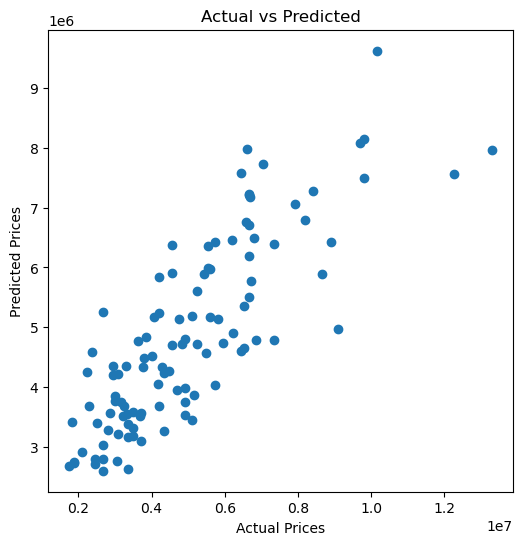

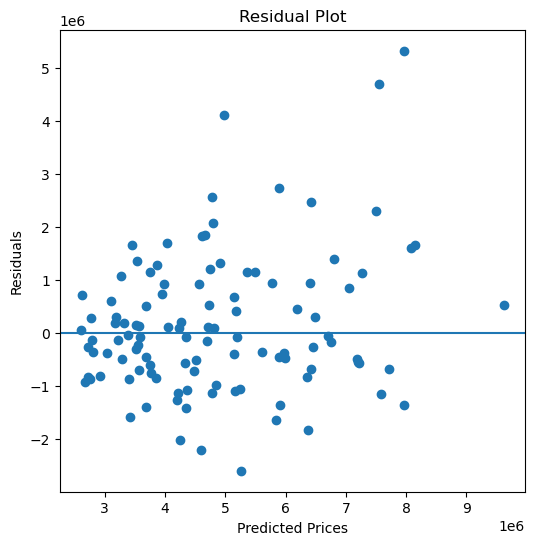

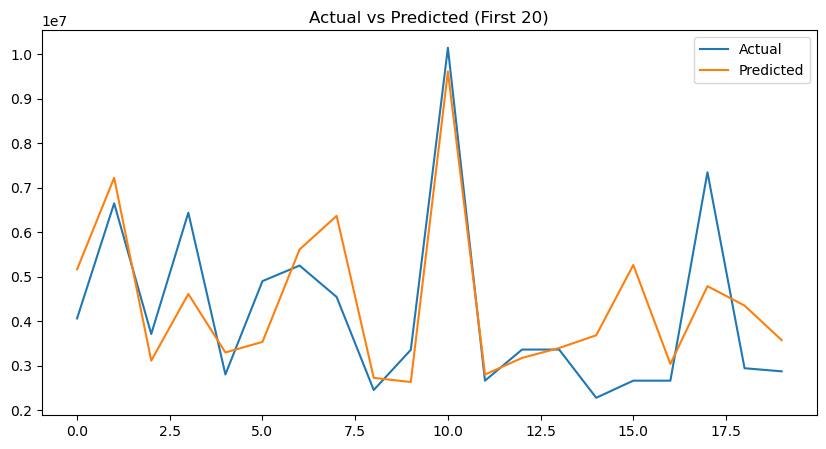

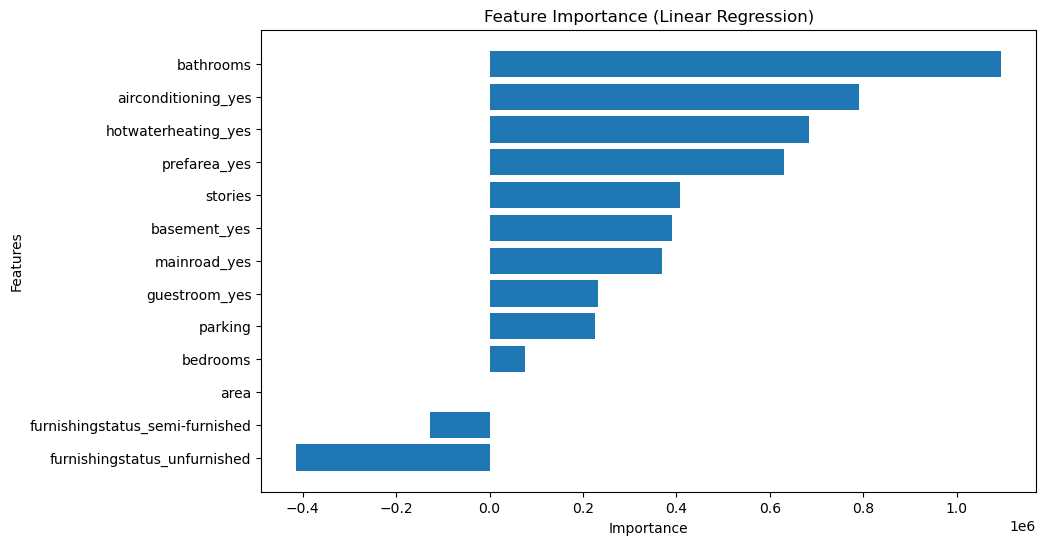

Sample Predicted Price: 5164653.900339673


In [7]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# ================================
# 2. Load Dataset
# ================================
data = pd.read_csv("Housing.csv")

print("First 5 rows:")
display(data.head())

# ================================
# 3. Data Preprocessing
# ================================
data = pd.get_dummies(data, drop_first=True)

X = data.drop("price", axis=1)
y = data["price"]

# ================================
# 4. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 5. Model Training
# ================================
model = LinearRegression()
model.fit(X_train, y_train)

# ================================
# 6. Prediction
# ================================
y_pred = model.predict(X_test)

# ================================
# 7. Evaluation
# ================================
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

# ================================
# 8. Actual vs Predicted Plot
# ================================
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

# ================================
# 9. Residual Plot
# ================================
residuals = y_test - y_pred

plt.figure(figsize=(6,6))
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.axhline(y=0)
plt.show()

# ================================
# 10. Line Plot (First 20 values)
# ================================
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:20], label="Actual")
plt.plot(y_pred[:20], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted (First 20)")
plt.show()

# ================================
# 11. Feature Importance
# ================================
importance = model.coef_
feature_names = X.columns

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance (Linear Regression)")
plt.gca().invert_yaxis()
plt.show()

# ================================
# 12. Sample Prediction (FIXED)
# ================================
sample = X_test.iloc[[0]]   # FIX: keeps column names
predicted_price = model.predict(sample)

print("Sample Predicted Price:", predicted_price[0])